In [1]:
from dask.distributed import Client, LocalCluster
from glob import glob
import os
import xarray as xr
from time import time

In [ ]:
cluster = LocalCluster(
    n_workers=24,          # one per physical core
    threads_per_worker=1,  
    memory_limit="6GB"     
)
client1 = Client(cluster)

In [2]:
netsw_path = glob(os.path.join("data/net_shortwave_eur_v3",'*.nc'))

In [3]:
netsw_path

['D:\\ServerUsers\\ge58som\\net_shortwave_eur_v3\\net_shortwave_eur_2001.nc',
 'D:\\ServerUsers\\ge58som\\net_shortwave_eur_v3\\net_shortwave_eur_2002.nc',
 'D:\\ServerUsers\\ge58som\\net_shortwave_eur_v3\\net_shortwave_eur_2003.nc',
 'D:\\ServerUsers\\ge58som\\net_shortwave_eur_v3\\net_shortwave_eur_2004.nc',
 'D:\\ServerUsers\\ge58som\\net_shortwave_eur_v3\\net_shortwave_eur_2005.nc',
 'D:\\ServerUsers\\ge58som\\net_shortwave_eur_v3\\net_shortwave_eur_2006.nc',
 'D:\\ServerUsers\\ge58som\\net_shortwave_eur_v3\\net_shortwave_eur_2007.nc',
 'D:\\ServerUsers\\ge58som\\net_shortwave_eur_v3\\net_shortwave_eur_2008.nc',
 'D:\\ServerUsers\\ge58som\\net_shortwave_eur_v3\\net_shortwave_eur_2009.nc',
 'D:\\ServerUsers\\ge58som\\net_shortwave_eur_v3\\net_shortwave_eur_2010.nc',
 'D:\\ServerUsers\\ge58som\\net_shortwave_eur_v3\\net_shortwave_eur_2011.nc',
 'D:\\ServerUsers\\ge58som\\net_shortwave_eur_v3\\net_shortwave_eur_2012.nc',
 'D:\\ServerUsers\\ge58som\\net_shortwave_eur_v3\\net_shortwave_

In [4]:
netlw_path = glob(os.path.join("data/ELITE_netLW",'*.zarr'))

In [5]:
netlw_path

['Z:\\Lehre\\Austausch\\x_Mahajan\\data\\ELITE_netLW\\netLW_2001.zarr',
 'Z:\\Lehre\\Austausch\\x_Mahajan\\data\\ELITE_netLW\\netLW_2002.zarr',
 'Z:\\Lehre\\Austausch\\x_Mahajan\\data\\ELITE_netLW\\netLW_2003.zarr',
 'Z:\\Lehre\\Austausch\\x_Mahajan\\data\\ELITE_netLW\\netLW_2004.zarr',
 'Z:\\Lehre\\Austausch\\x_Mahajan\\data\\ELITE_netLW\\netLW_2005.zarr',
 'Z:\\Lehre\\Austausch\\x_Mahajan\\data\\ELITE_netLW\\netLW_2006.zarr',
 'Z:\\Lehre\\Austausch\\x_Mahajan\\data\\ELITE_netLW\\netLW_2007.zarr',
 'Z:\\Lehre\\Austausch\\x_Mahajan\\data\\ELITE_netLW\\netLW_2008.zarr',
 'Z:\\Lehre\\Austausch\\x_Mahajan\\data\\ELITE_netLW\\netLW_2009.zarr',
 'Z:\\Lehre\\Austausch\\x_Mahajan\\data\\ELITE_netLW\\netLW_2010.zarr',
 'Z:\\Lehre\\Austausch\\x_Mahajan\\data\\ELITE_netLW\\netLW_2011.zarr',
 'Z:\\Lehre\\Austausch\\x_Mahajan\\data\\ELITE_netLW\\netLW_2012.zarr',
 'Z:\\Lehre\\Austausch\\x_Mahajan\\data\\ELITE_netLW\\netLW_2013.zarr',
 'Z:\\Lehre\\Austausch\\x_Mahajan\\data\\ELITE_netLW\\netLW_2014

In [6]:
net_sw = xr.open_mfdataset(netsw_path, chunks = {'time': 90, 'lat': 1000, 'lon': 500})

C:\Users\ge58som\AppData\Local\Temp\45\ipykernel_106732\904690099.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 1000. This could degrade performance. Instead, consider rechunking after loading.
  net_sw = xr.open_mfdataset(netsw_path, chunks = {'time': 90, 'lat': 1000, 'lon': 500})
C:\Users\ge58som\AppData\Local\Temp\45\ipykernel_106732\904690099.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "lon" starting at index 500. This could degrade performance. Instead, consider rechunking after loading.
  net_sw = xr.open_mfdataset(netsw_path, chunks = {'time': 90, 'lat': 1000, 'lon': 500})
C:\Users\ge58som\AppData\Local\Temp\45\ipykernel_106732\904690099.py:1: UserWarning: The specified chunks separate the stored chunks along dimension "lat" starting at index 1000. This could degrade performance. Instead, consider rechunking after loading.
  net_sw = xr.open_mfdataset(netsw_path, chunks = {'time':

In [7]:
net_lw = xr.open_mfdataset(netlw_path, engine = 'zarr')

In [8]:
net_sw

<xarray.Dataset> Size: 786GB
Dimensions:        (time: 7305, lat: 2970, lon: 4530)
Coordinates:
  * lon            (lon) float64 36kB -25.24 -25.23 -25.21 ... 50.21 50.22 50.24
  * lat            (lat) float64 24kB 72.24 72.22 72.21 ... 22.79 22.77 22.76
  * time           (time) datetime64[ns] 58kB 2001-01-01 ... 2020-12-31
Data variables:
    shortwave_net  (time, lat, lon) float64 786GB dask.array<chunksize=(90, 1000, 500), meta=np.ndarray>

In [9]:
net_lw

<xarray.Dataset> Size: 393GB
Dimensions:       (time: 7305, lat: 2970, lon: 4530)
Coordinates:
  * lat           (lat) float64 24kB 72.24 72.22 72.21 ... 22.79 22.77 22.76
  * lon           (lon) float64 36kB -25.24 -25.23 -25.21 ... 50.21 50.22 50.24
  * time          (time) datetime64[ns] 58kB 2001-01-01 ... 2020-12-31
Data variables:
    longwave_net  (time, lat, lon) float32 393GB dask.array<chunksize=(90, 1000, 1000), meta=np.ndarray>

In [10]:
net_rad = net_sw['shortwave_net'] + net_lw['longwave_net']

In [11]:
net_rad = net_rad.astype('float32')

In [12]:
net_rad

<xarray.DataArray (time: 7305, lat: 2970, lon: 4530)> Size: 393GB
dask.array<astype, shape=(7305, 2970, 4530), dtype=float32, chunksize=(90, 1000, 500), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 36kB -25.24 -25.23 -25.21 ... 50.21 50.22 50.24
  * lat      (lat) float64 24kB 72.24 72.22 72.21 72.19 ... 22.79 22.77 22.76
  * time     (time) datetime64[ns] 58kB 2001-01-01 2001-01-02 ... 2020-12-31

In [13]:
rad_fluxes = xr.Dataset({
    'net_radiation': net_rad
})

In [14]:
rad_fluxes.attrs['title'] = "Net radiation for Europe"
rad_fluxes.attrs['author'] = "Karan Mahajan, karanmahajan.chd@gmail.com"
rad_fluxes.attrs['spatial_res'] = '1 arcmin: around 1.8km at Equator and around 1.4km for Europe. Same grid as EMO1 v3.0.0 dataset'
rad_fluxes.attrs['temporal_res'] = 'daily'
rad_fluxes.attrs['description'] = "20-year dataset of net radiation for Europe. GLASS albedo, BESS PAR and BESS PARDiff products were used to compute blue sky albedo. Then EMO1 downwelling shortwave radiation and blue sky albedo were used to calculate the net shortwave radiation. Net longwave radiation taken from ELITE SLUR and SLDR products."

In [15]:
rad_fluxes

<xarray.Dataset> Size: 393GB
Dimensions:        (lon: 4530, lat: 2970, time: 7305)
Coordinates:
  * lon            (lon) float64 36kB -25.24 -25.23 -25.21 ... 50.21 50.22 50.24
  * lat            (lat) float64 24kB 72.24 72.22 72.21 ... 22.79 22.77 22.76
  * time           (time) datetime64[ns] 58kB 2001-01-01 ... 2020-12-31
Data variables:
    net_radiation  (time, lat, lon) float32 393GB dask.array<chunksize=(90, 1000, 500), meta=np.ndarray>
Attributes:
    title:         Net radiation for Europe
    author:        Karan Mahajan, karanmahajan.chd@gmail.com
    spatial_res:   1 arcmin: around 1.8km at Equator and around 1.4km for Eur...
    temporal_res:  daily
    description:   20-year dataset of net radiation for Europe. GLASS albedo,...

In [16]:
# Specify compression encoding
encoding = {
    'net_radiation': { 'zlib': True, 'complevel': 5}
    }


In [17]:
t_tot_0 = time()
for year, data in rad_fluxes.groupby('time.year'):
    t0 = time()
    print(f'Currently saving netCDF file for year : {year}')
    data.to_netcdf(f"data/net_rad_eur/net_rad_eur_{year}.nc', engine='h5netcdf', encoding=encoding)
    print(f"Time elapsed to save netCDF file for year {year}: {(time()-t0)/60} minutes\n")
    
print(f'Time elapsed to save all the netCDF files: {(time()-t_tot_0)/60} minutes')

Currently saving netCDF file for year : 2001
Time elapsed to save netCDF file for year 2001: 35.75610917409261 minutes

Currently saving netCDF file for year : 2002
Time elapsed to save netCDF file for year 2002: 37.42636498610179 minutes

Currently saving netCDF file for year : 2003
Time elapsed to save netCDF file for year 2003: 37.11766014099121 minutes

Currently saving netCDF file for year : 2004
Time elapsed to save netCDF file for year 2004: 37.41754054228465 minutes

Currently saving netCDF file for year : 2005
Time elapsed to save netCDF file for year 2005: 36.82846277157466 minutes

Currently saving netCDF file for year : 2006
Time elapsed to save netCDF file for year 2006: 36.73980768521627 minutes

Currently saving netCDF file for year : 2007
Time elapsed to save netCDF file for year 2007: 36.9444330851237 minutes

Currently saving netCDF file for year : 2008
Time elapsed to save netCDF file for year 2008: 36.779796759287514 minutes

Currently saving netCDF file for year : 

In [28]:
chk = xr.open_dataset("data/net_rad_eur_2002.nc", engine="h5netcdf")

In [29]:
chk

<xarray.Dataset> Size: 20GB
Dimensions:        (lon: 4530, lat: 2970, time: 365)
Coordinates:
  * lon            (lon) float64 36kB -25.24 -25.23 -25.21 ... 50.21 50.22 50.24
  * lat            (lat) float64 24kB 72.24 72.22 72.21 ... 22.79 22.77 22.76
  * time           (time) datetime64[ns] 3kB 2002-01-01 ... 2002-12-31
Data variables:
    net_radiation  (time, lat, lon) float32 20GB ...
Attributes:
    title:         Net radiation for Europe
    author:        Karan Mahajan, karanmahajan.chd@gmail.com
    spatial_res:   1 arcmin: around 1.8km at Equator and around 1.4km for Eur...
    temporal_res:  daily
    description:   20-year dataset of net radiation for Europe. GLASS albedo,...

In [25]:
rad_fluxes

<xarray.Dataset> Size: 393GB
Dimensions:        (lon: 4530, lat: 2970, time: 7305)
Coordinates:
  * lon            (lon) float64 36kB -25.24 -25.23 -25.21 ... 50.21 50.22 50.24
  * lat            (lat) float64 24kB 72.24 72.22 72.21 ... 22.79 22.77 22.76
  * time           (time) datetime64[ns] 58kB 2001-01-01 ... 2020-12-31
Data variables:
    net_radiation  (time, lat, lon) float32 393GB dask.array<chunksize=(90, 1000, 500), meta=np.ndarray>
Attributes:
    title:         Net radiation for Europe
    author:        Karan Mahajan, karanmahajan.chd@gmail.com
    spatial_res:   1 arcmin: around 1.8km at Equator and around 1.4km for Eur...
    temporal_res:  daily
    description:   20-year dataset of net radiation for Europe. GLASS albedo,...

In [26]:
net_rad

<xarray.DataArray (time: 7305, lat: 2970, lon: 4530)> Size: 393GB
dask.array<astype, shape=(7305, 2970, 4530), dtype=float32, chunksize=(90, 1000, 500), chunktype=numpy.ndarray>
Coordinates:
  * lon      (lon) float64 36kB -25.24 -25.23 -25.21 ... 50.21 50.22 50.24
  * lat      (lat) float64 24kB 72.24 72.22 72.21 72.19 ... 22.79 22.77 22.76
  * time     (time) datetime64[ns] 58kB 2001-01-01 2001-01-02 ... 2020-12-31

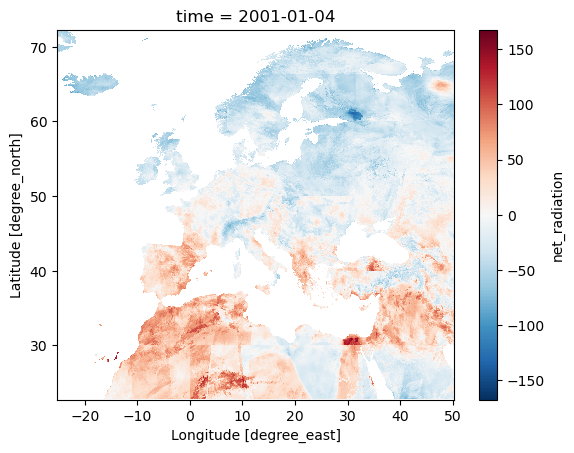

In [27]:
rad_fluxes.net_radiation.isel(time=3).plot()